# Abalone age predictor

## Goal
In this dataset, we will create a model, which will predict the age of an abalone tree.

## Why this dataset?
This dataset has lots of continuous data, which is also numeric. This combination will make our model very accurate and will prevent having problems in preprocessing the dataset.

## Variables
| Variable Name | Role | Type | Description | Units | Missing Values |
|---|---|---|---|---|---|
| Sex | Feature | Categorical | M, F, and I (infant) |  | no |
| Length | Feature | Continuous | Longest shell measurement | mm | no |
| Diameter | Feature | Continuous | perpendicular to length | mm | no |
| Height | Feature | Continuous | with meat in shell | mm | no |
| Whole_weight | Feature | Continuous | whole abalone | grams | no |
| Shucked_weight | Feature | Continuous | weight of meat | grams | no |
| Viscera_weight | Feature | Continuous | gut weight (after bleeding) | grams | no |
| Shell_weight | Feature | Continuous | after being dried | grams | no |
| Rings | Target | Integer | +1.5 gives the age in years |  | no |
| Age | Target | Integer | Calculated from the rings |  | no |

## Link
https://archive.ics.uci.edu/dataset/1/abalone

## 1. Importing the packages

In [799]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2. Preprocessing

In [800]:
# Combine features and target into one pandas DataFrame
abalone = fetch_ucirepo(id=1) 
x = abalone.data.features 
y = abalone.data.targets 
  
df = x.copy()
if y is not None and not y.empty:
    df = pd.concat([df, y], axis=1)

print(type(df))
print(df.shape)
df.head()

<class 'pandas.DataFrame'>
(4177, 9)


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


`First, as we see we have no data missing in the table. The only data row we are missing is the age. We can create it by adding 1.5 to the rings. This information is vital for our research, so let's make it. We will also drop both age and rings for our X axis, because those are Targets and not features.

In [801]:
Y = df["Age"] = df["Rings"] + 1.5
X = df.drop(columns=["Rings", "Age"])
Y = df["Age"]

Now we will preprocess all the data into two pipelines, make the categories binary columns and transform the numerical values.

In [802]:
num_cols = X.select_dtypes(exclude=["object"]).columns
cat_cols = X.select_dtypes(include=["object", "str"]).columns

num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

## Searching for the outliers

In [803]:
# Calculate outliers using the IQR method for the numeric columns
Q1 = X[num_cols].quantile(0.25)
Q3 = X[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = ((X[num_cols] < lower_bound) | (X[num_cols] > upper_bound)).sum()

print('Outliers per numeric column:')
print(outlier_counts)
print(f'Total outliers across all numeric columns: {outlier_counts.sum()}')

Outliers per numeric column:
Length            49
Diameter          59
Height            29
Whole_weight      30
Shucked_weight    48
Viscera_weight    26
Shell_weight      35
dtype: int64
Total outliers across all numeric columns: 276


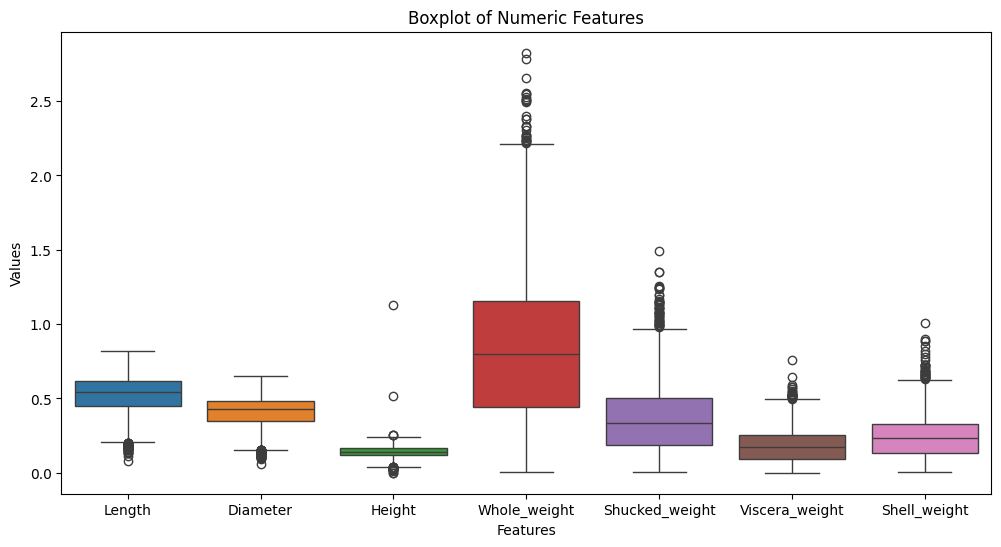

In [804]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=X[num_cols])
plt.title('Boxplot of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Values')
plt.show()

As seen in the boxplots abovem does the height and height variables have some high outliers. We need to remove them in the future

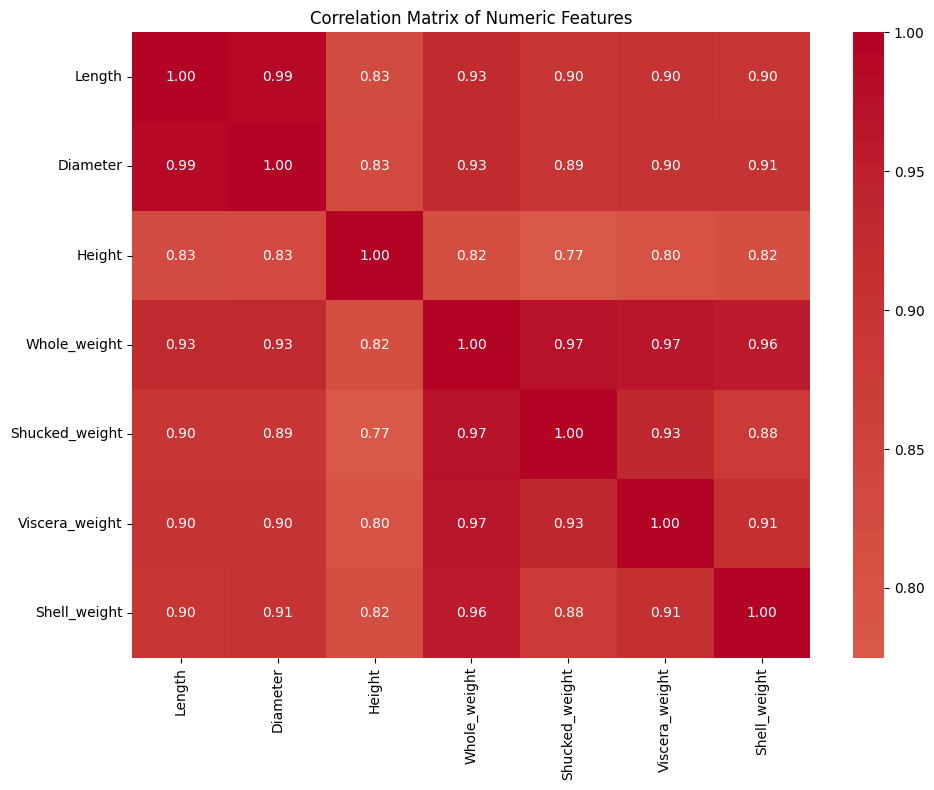

In [805]:
# Correlation matrix for the numeric features
corr_matrix = X[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

As we see, the correlation between all the data in our dataset is very high, so the accuracy of our model may be also very high. The only feature having a lower correlation is height. Due to having such high correlation, we have a chance of having multicollinearity. Let's check and fix that.

In [806]:
# Fit the preprocessor on the full X
preprocessor.fit(X)

# Transform X into the numeric design matrix
X_transformed = preprocessor.transform(X)
X_transformed_dense = X_transformed.toarray() if hasattr(X_transformed, "toarray") else np.asarray(X_transformed)

num_features = preprocessor.named_transformers_["num"].get_feature_names_out(num_cols)
cat_encoder = preprocessor.named_transformers_["cat"]["onehot"]
cat_features = cat_encoder.get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_features, cat_features])

# Convert into a DataFrame
X_vif = pd.DataFrame(X_transformed_dense, columns=feature_names, index=X.index)

# Calculate VIF for each feature
vif_list = []
for i in range(X_vif.shape[1]):
    vif = variance_inflation_factor(X_vif.values, i)
    vif_list.append(vif)

vif_df = pd.DataFrame({
    "Feature": feature_names,
    "VIF": vif_list
})

vif_df.sort_values("VIF", ascending=False).head(20)

,Feature,VIF
3,Whole_weight,109.768710
1,Diameter,42.379841
0,Length,40.945763
4,Shucked_weight,28.550546
6,Shell_weight,21.263272
5,Viscera_weight,17.445012
2,Height,3.581369
8,Sex_I,1.354667
7,Sex_F,1.122865
9,Sex_M,1.061499


Oh no... As we see, the VIF is far above 10, which is no good. This means there is lots of redundant data. To fix this, we will remove some weight variables to leave only one and remove the diameter. because it has the highest VIF of the non-weight data.

In [807]:
# Reduce multicollinearity by dropping the most redundant columns
cols_to_drop = ["Whole_weight", "Diameter", "Shucked_weight", "Viscera_weight"]
X_reduced = X.drop(columns=cols_to_drop).copy()

# Build a new preprocessor for the reduced feature set
num_cols_reduced = X_reduced.select_dtypes(exclude=["object"]).columns
cat_cols_reduced = X_reduced.select_dtypes(include=["object", "str"]).columns

num_pipeline_reduced = Pipeline(steps=[
    ("scaler", StandardScaler())
])
cat_pipeline_reduced = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_reduced = ColumnTransformer([
    ("num", num_pipeline_reduced, num_cols_reduced),
    ("cat", cat_pipeline_reduced, cat_cols_reduced)
])

In [808]:
# Recompute VIF on reduced features
preprocessor_reduced.fit(X_reduced)
X_reduced_transformed = preprocessor_reduced.transform(X_reduced)
X_reduced_transformed_dense = X_reduced_transformed.toarray() if hasattr(X_reduced_transformed, "toarray") else np.asarray(X_reduced_transformed)

num_features_reduced = preprocessor_reduced.named_transformers_["num"].get_feature_names_out(num_cols_reduced)
cat_encoder_reduced = preprocessor_reduced.named_transformers_["cat"]["onehot"]
cat_features_reduced = cat_encoder_reduced.get_feature_names_out(cat_cols_reduced)
feature_names_reduced = np.concatenate([num_features_reduced, cat_features_reduced])

X_vif_reduced = pd.DataFrame(X_reduced_transformed_dense, columns=feature_names_reduced, index=X_reduced.index)

vif_list_reduced = []
for i in range(X_vif_reduced.shape[1]):
    vif_list_reduced.append(variance_inflation_factor(X_vif_reduced.values, i))

vif_df_reduced = pd.DataFrame({
    "Feature": feature_names_reduced,
    "VIF": vif_list_reduced
})

vif_df_reduced.sort_values("VIF", ascending=False).reset_index(drop=True)

,Feature,VIF
0,Length,6.052576
1,Shell_weight,5.730444
2,Height,3.524184
3,Sex_I,1.327645
4,Sex_F,1.105767
5,Sex_M,1.055741


Much better! VIF around 6 is acceptable, and now we can train a model using this data.

In [809]:
from math import sqrt


X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, Y, test_size=0.2, random_state=42
)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []
residuals = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor_reduced),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    results.append((name, r2, rmse))

    residuals[name] = y_test - y_pred  # store residuals for later

results_df = pd.DataFrame(results, columns=["Model", "R²", "RMSE"]).sort_values("R²", ascending=False)
results_df

,Model,R²,RMSE
1,Ridge,0.427090,2.490355
0,Linear,0.427081,2.490374
3,ElasticNet,0.417512,2.511087
2,Lasso,0.412298,2.522300


As seen above, the results between models are almost identical. All models have almost same performance with this dataset.

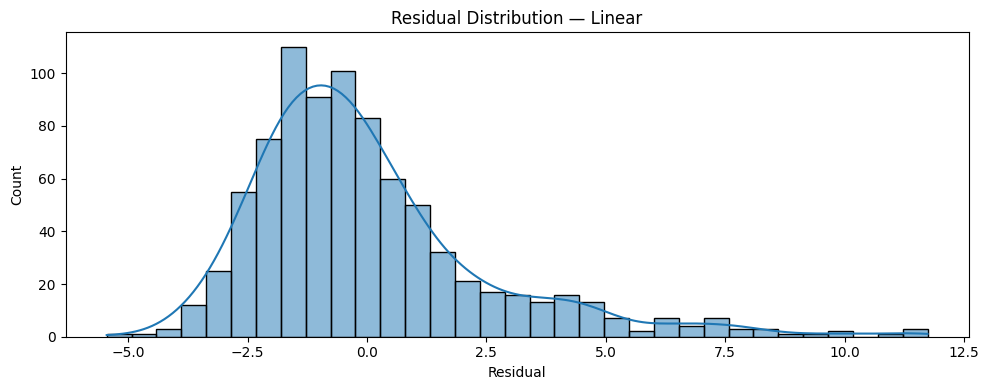

Shapiro-Wilk (Linear): statistic=0.8829, p=1.2990e-24


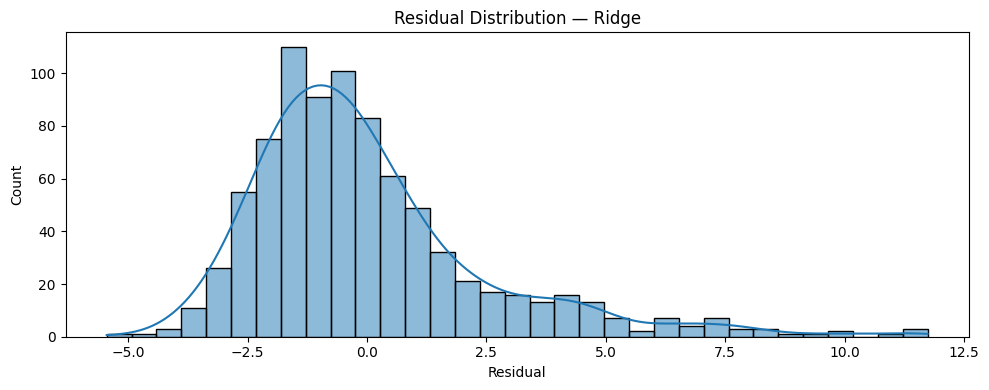

Shapiro-Wilk (Ridge): statistic=0.8828, p=1.2623e-24


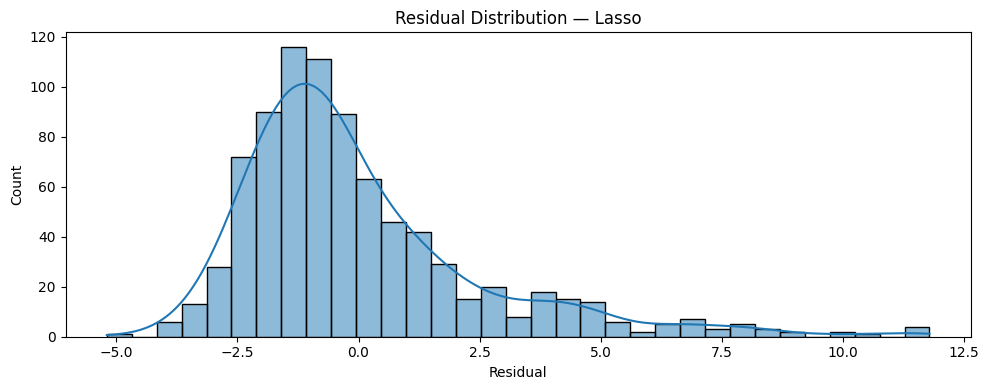

Shapiro-Wilk (Lasso): statistic=0.8617, p=1.7869e-26


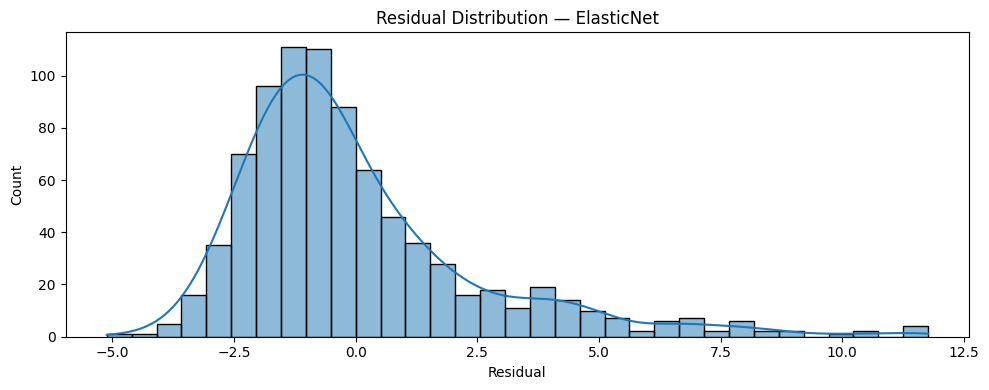

Shapiro-Wilk (ElasticNet): statistic=0.8607, p=1.4780e-26


In [810]:
def plot_residual_diagnostics(model_name, resid):
    # Make sure resid is a clean 1D array (no NaNs)
    resid = np.asarray(resid).ravel()
    resid = resid[~np.isnan(resid)]

    fig, ax = plt.subplots(figsize=(10, 4))

    # Histogram + KDE
    sns.histplot(resid, kde=True, ax=ax)
    ax.set_title(f"Residual Distribution — {model_name}")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    # Shapiro test (note: can be overly sensitive for large n)
    stat, p = stats.shapiro(resid)
    print(f"Shapiro-Wilk ({model_name}): statistic={stat:.4f}, p={p:.4e}")

# Example usage: residuals should be a dict like {"Model A": resid_array, ...}
for model_name, resid in residuals.items():
    print("=" * 70)
    plot_residual_diagnostics(model_name, resid)

As we see, the p-value is shockingly low, which means that we're dealing with a not normal distribution of data. We can try a non-linair model to see if the results will be any better.

In [811]:
poly = Pipeline([
    ('prep', preprocessor_reduced),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

poly.fit(X_train, y_train)
y_pred_poly = poly.predict(X_test)
print('R² (polynomial):', r2_score(y_test, y_pred_poly))

R² (polynomial): 0.4706535782945078


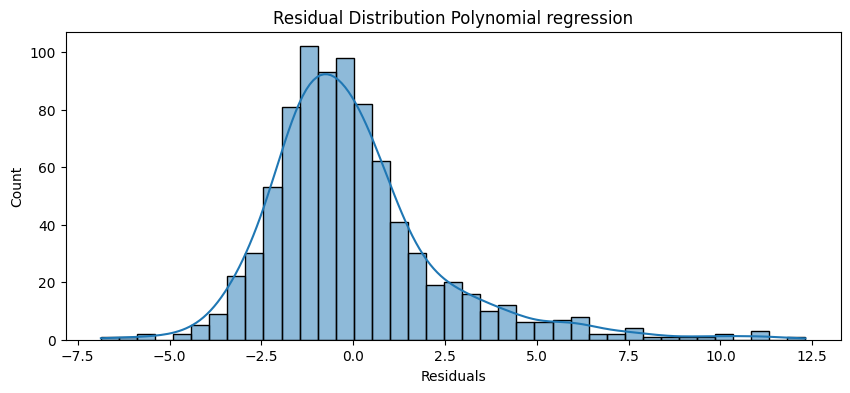

Shapiro-Wilk test: ShapiroResult(statistic=np.float64(0.8994688685374281), pvalue=np.float64(5.664258206312323e-23))


In [812]:
residuals_poly = y_test - y_pred_poly
plt.figure(figsize=(10,4))
sns.histplot(residuals_poly, kde=True)
plt.title(f"Residual Distribution Polynomial regression")
plt.xlabel("Residuals")
plt.show()

# Normality test (Shapiro-Wilk)
shapiro_test_poly = stats.shapiro(residuals_poly)
print("Shapiro-Wilk test:", shapiro_test_poly)

The polynomial regression seems to perform a bit better with this data. Though, the p-value is still very low, due to the distribution of data.

In [813]:
df_clean = df.copy()

X_clean = df_clean.drop(columns=["Age", "Rings"]).copy()
Y_clean = df_clean["Age"].copy()

X_train_clean_raw, X_test_clean_raw, y_train_clean, y_test_clean = train_test_split(
    X_clean, Y_clean, test_size=0.2, random_state=42
)

# Fit capping thresholds on the training split only
cap_cols = ["Length", "Shell_weight", "Height"]
cap_quantile = 0.95
caps = X_train_clean_raw[cap_cols].quantile(cap_quantile)

# Apply the same caps to train and test
X_train_clean = X_train_clean_raw.copy()
X_test_clean = X_test_clean_raw.copy()

for col in cap_cols:
    X_train_clean[col] = X_train_clean[col].clip(upper=caps[col])
    X_test_clean[col] = X_test_clean[col].clip(upper=caps[col])

# Remove redundant columns after the split to avoid leakage
cols_to_drop = ["Whole_weight", "Diameter", "Shucked_weight", "Viscera_weight"]
X_train_clean = X_train_clean.drop(columns=cols_to_drop).copy()
X_test_clean = X_test_clean.drop(columns=cols_to_drop).copy()

# Build a preprocessor directly from the cleaned training columns
num_cols_clean = X_train_clean.select_dtypes(exclude=["object"]).columns
cat_cols_clean = X_train_clean.select_dtypes(include=["object", "str"]).columns

preprocessor_clean = ColumnTransformer([
    ("num", Pipeline([("scaler", StandardScaler())]), num_cols_clean),
    ("cat", Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols_clean),
])

print("Leakage-safe cleaned split prepared.")
print("Train shape:", X_train_clean.shape)
print("Test shape:", X_test_clean.shape)

Leakage-safe cleaned split prepared.
Train shape: (3341, 4)
Test shape: (836, 4)


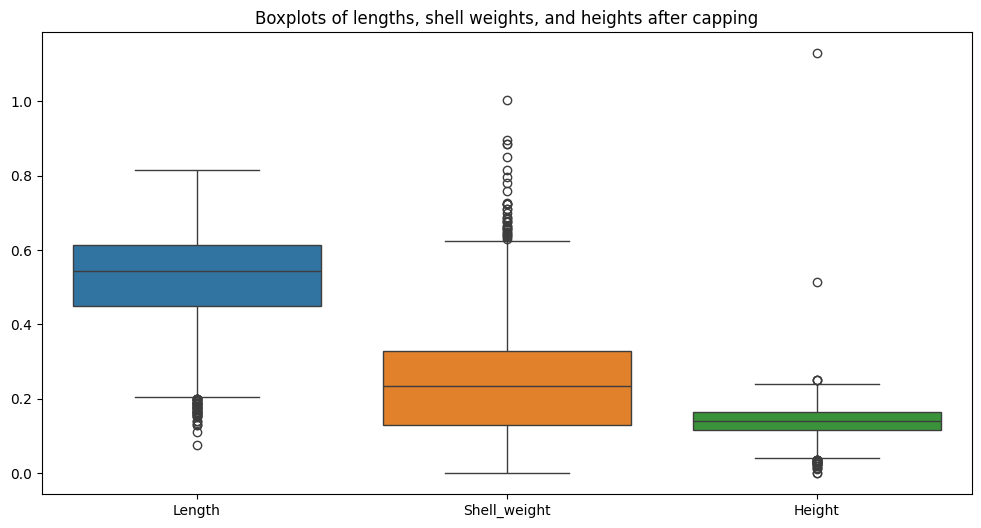

In [814]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean[["Length","Shell_weight","Height"]])
plt.title("Boxplots of lengths, shell weights, and heights after capping")
plt.show()

In [815]:
# Refit models on the cleaned reduced-feature dataset
results_clean = []
residuals_clean = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor_clean),
        ("model", model)
    ])

    pipe.fit(X_train_clean, y_train_clean)
    y_pred_clean = pipe.predict(X_test_clean)

    r2_clean = r2_score(y_test_clean, y_pred_clean)
    rmse_clean = sqrt(mean_squared_error(y_test_clean, y_pred_clean))
    results_clean.append((name, r2_clean, rmse_clean))

    residuals_clean[name] = y_test_clean - y_pred_clean

results_df_clean = pd.DataFrame(results_clean, columns=["Model", "R²", "RMSE"]).sort_values("R²", ascending=False)
results_df_clean

,Model,R²,RMSE
1,Ridge,0.416553,2.513154
0,Linear,0.416501,2.513265
3,ElasticNet,0.408129,2.531231
2,Lasso,0.403093,2.541976


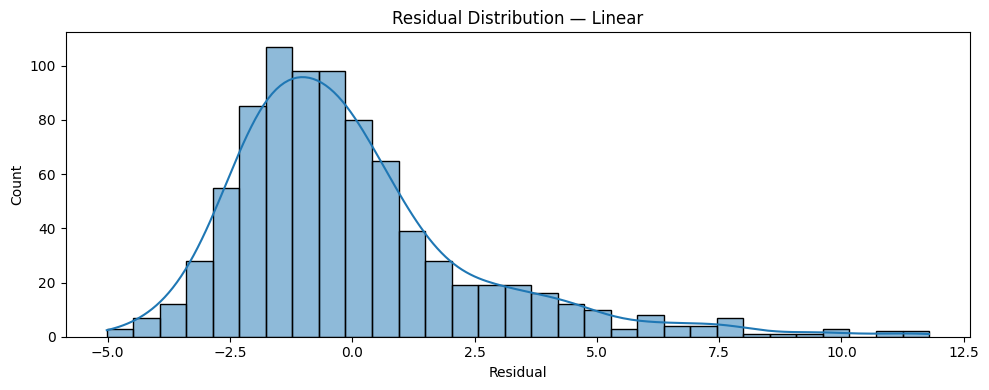

Shapiro-Wilk (Linear): statistic=0.8915, p=8.6854e-24


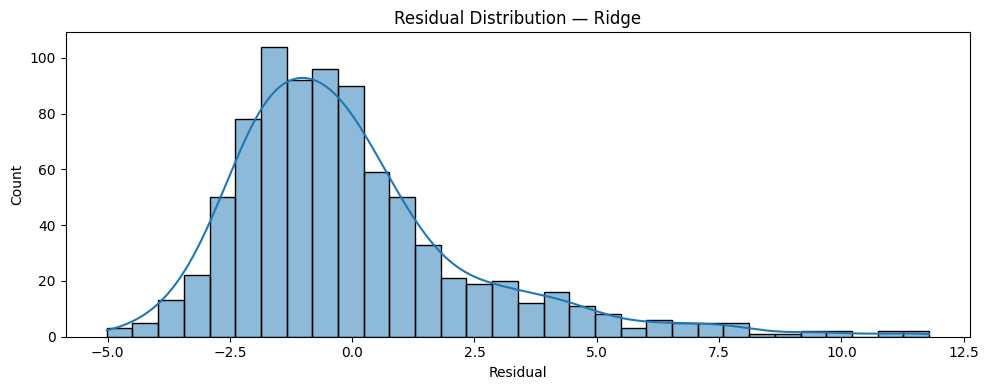

Shapiro-Wilk (Ridge): statistic=0.8913, p=8.3253e-24


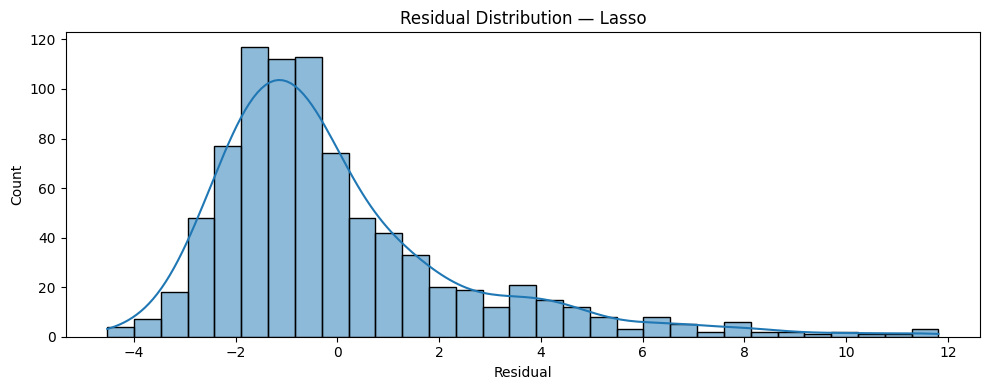

Shapiro-Wilk (Lasso): statistic=0.8595, p=1.1787e-26


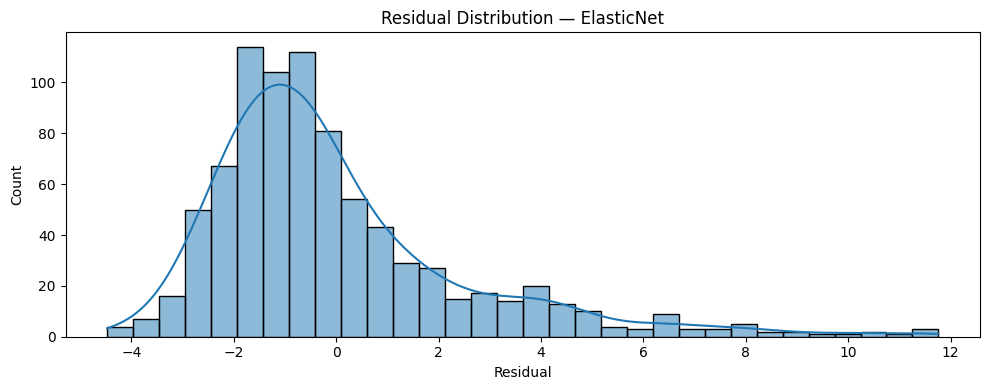

Shapiro-Wilk (ElasticNet): statistic=0.8602, p=1.3446e-26


In [816]:
for model_name, resid in residuals_clean.items():
    print("="*70)
    plot_residual_diagnostics(model_name, resid)

As visible here, the p value didn't change much, which means that there is something else going on with the dataset. As last option, we may try using the gradient boosting regression for training our model.

In [817]:
gbr = Pipeline([
    ("preprocess", preprocessor_clean),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gbr.fit(X_train_clean, y_train_clean)
y_pred_gbr = gbr.predict(X_test_clean)

r2_gbr = r2_score(y_test_clean, y_pred_gbr)
rmse_gbr = sqrt(mean_squared_error(y_test_clean, y_pred_gbr))

results_df_clean.loc[len(results_df_clean)] = [
    "GradientBoosting", r2_gbr, rmse_gbr
]

results_df_clean.sort_values("R²", ascending=False)

,Model,R²,RMSE
4,GradientBoosting,0.478996,2.374864
1,Ridge,0.416553,2.513154
0,Linear,0.416501,2.513265
3,ElasticNet,0.408129,2.531231
2,Lasso,0.403093,2.541976


**Result**: After testing 5 different models, we can conclude that Gradient boosting is getting the highest R^2 and lowest root mean square error from all of them. To sum up, we can execute a cross-validation to be sure, that gradient boosting will have a good model performance.

In [818]:
cv_scores = cross_val_score(
    gbr,
    X_train_clean,
    y_train_clean,
    cv=5,
    scoring="r2"
)

print("Gradient Boosting CV R² mean:", cv_scores.mean())
print("Gradient Boosting CV R² std :", cv_scores.std())


Gradient Boosting CV R² mean: 0.48358462664256674
Gradient Boosting CV R² std : 0.017649441623115887


As we can see, the std is now low, which means it behaves consistently.
Also, we can see that the model explains 48% variance in age, which means the model has a good performance. Now we will save the model and deploy it using streamline.

## Saving the model and deployment

In [819]:

model_path = "abalone_age_gbr.pkl"

joblib.dump(gbr, "abalone_age_gbr.pkl")
print("Model saved:", model_path)

Model saved: abalone_age_gbr.pkl
